In [3]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import skimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu
import random

plt.style.use('styleNB.mplstyle')




In [4]:
f_compiled = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_tracking.csv'

df = pd.read_csv(f_compiled)
df = df[['cell', 'frame', 'x', 'y', 'z', 'celltype', 'E_V_cm',
       'date', 'trial', 'user']]
df = df[df.celltype != 'dHL60TMEM154KO-clone1galvanin-GFP-HA']

f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]


df = pd.concat([df, df_gfp], ignore_index = True)
df = df[df.E_V_cm != 5]
df = df.replace('dHL60TMEM154KO-clone1', 'dHL60TMEM154KO')
df = df.replace('dHL60TMEM154KO-clone12', 'dHL60TMEM154KO')

#  Step 1: Remove cells at the periphery
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20: #14:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)


# Step 3: subsample every three minutes
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

df.celltype.unique()

array(['dHL60KW', 'dHL60TMEM154KO',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'], dtype=object)

# Plotting of the HL-60 Galvanin knockout and rescue data.(i.e. Figure 2 data)

## Tracks

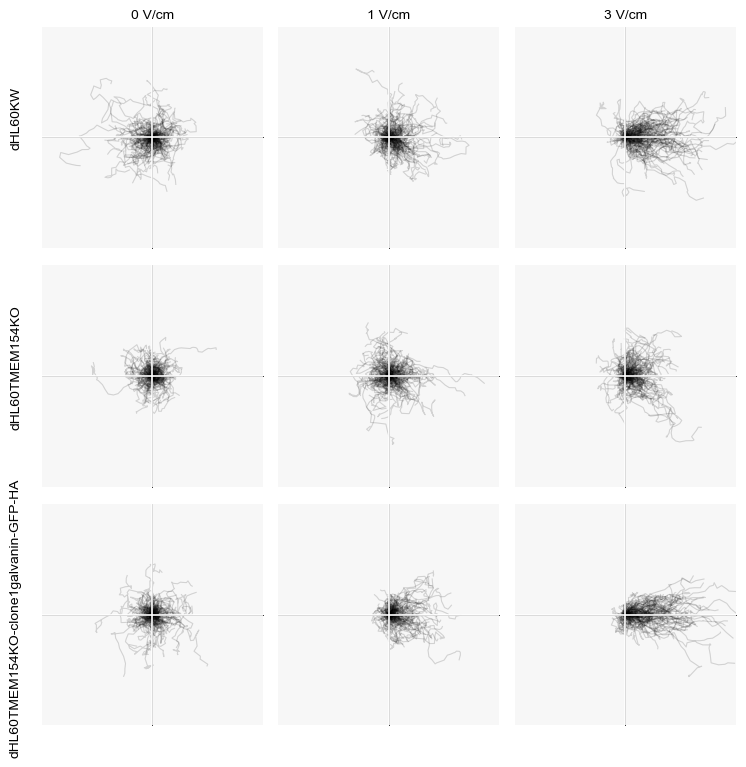

In [5]:
# Extract unique values
celltypes = sorted(df_filtered_tracks['celltype'].unique())
field_strengths = sorted(df_filtered_tracks['E_V_cm'].unique())

# Create subplot index maps
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}
EF_dict = {e: j for j, e in enumerate(field_strengths)}

n_rows = len(celltypes)
n_cols = len(field_strengths)

# Initialize subplots
f, ax = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows), squeeze=False)

for (celltype, E), d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    r = celltype_dict[celltype]
    c = EF_dict[E]
    ax_ = ax[r, c]

    count_cell = 0
    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell > 126:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)
        count_cell += 1

    # Format subplot
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.set_xlim(-200, 200)
    ax_.set_ylim(-200, 200)
    ax_.set_aspect('equal')
    ax_.set_axisbelow(True)
    ax_.set_facecolor('#f7f7f7')

    # Remove ticks and tick labels
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.tick_params(left=False, bottom=False)

    # Optional: Add title to top row
    if r == 0:
        ax_.set_title(f'{E} V/cm', fontsize=10)

# Add row labels (optional)
for r, celltype in enumerate(celltypes):
    f.text(0.01, 1 - (r + 0.5) / n_rows, celltype, va='center', ha='left', rotation='vertical', fontsize=10)

plt.tight_layout(rect=[0.03, 0, 1, 1])  # leave space on left for labels

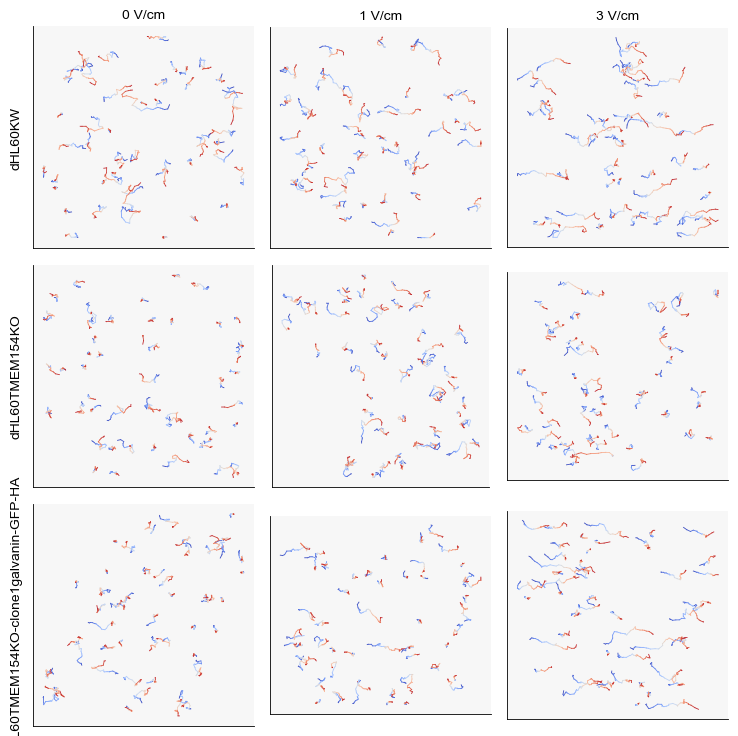

In [6]:


# Extract sorted unique values
celltypes = sorted(df_filtered_tracks['celltype'].unique())
field_strengths = sorted(df_filtered_tracks['E_V_cm'].unique())

# Create index mapping
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}
EF_dict = {e: j for j, e in enumerate(field_strengths)}

n_rows = len(celltypes)
n_cols = len(field_strengths)

# Image scale
ip = 0.642

# Max number of cells per plot
n_cells_per_group = 50

# Color map for time gradient
cmap = plt.get_cmap('coolwarm')

# Initialize full grid
fig, ax = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows), squeeze=False)

for (celltype, E), d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    r = celltype_dict[celltype]
    c = EF_dict[E]
    ax_ = ax[r, c]

    # Filter and sample valid cells
    valid_cells = [
        d_ for _, d_ in d.groupby(['cell', 'trial', 'date', 'user'])
        if len(d_) >= 15
    ]

    if not valid_cells:
        continue

    random.seed(0)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))

    # Plot each sampled trajectory with time-gradient color
    for d_ in sampled_cells:
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        for i in range(len(x) - 1):
            ax_.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Formatting
    ax_.set_aspect('equal')
    ax_.set_facecolor('#f7f7f7')
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.tick_params(left=False, bottom=False)

    if r == 0:
        ax_.set_title(f'{E} V/cm', fontsize=10)
    if c == 0:
        ax_.set_ylabel(celltype, fontsize=10)

# Layout adjustment
plt.tight_layout()

## Here are only plots of 300 mV/mm condition only - probably more useful for main text figures. 

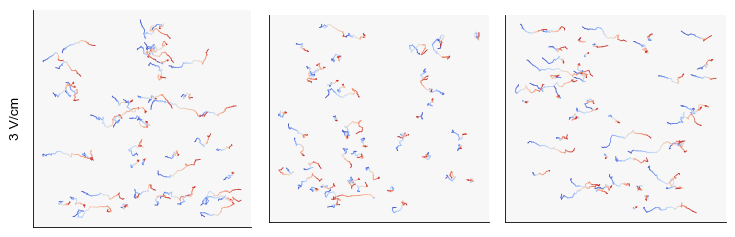

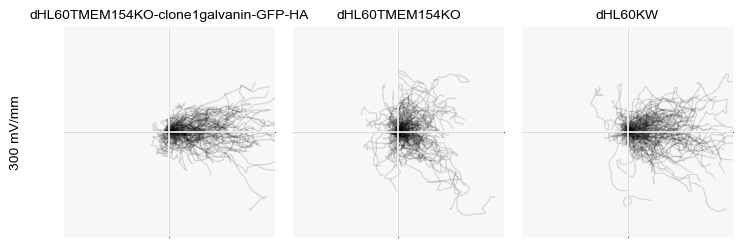

In [7]:
df_temp = df_filtered_tracks[df_filtered_tracks.E_V_cm == 3]

# Extract sorted unique values
celltypes = sorted(df_temp['celltype'].unique())

# Create index mapping
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

n_cols = len(celltypes) 

# Image scale
ip = 0.642

# Max number of cells per plot
n_cells_per_group = 50

# Color map for time gradient
cmap = plt.get_cmap('coolwarm')

# Initialize full grid
fig, ax = plt.subplots(1, n_cols, figsize=(2.5 * n_cols, 2.5 ), squeeze=False)

for (celltype, E), d in df_temp.groupby(['celltype', 'E_V_cm']):
    c = celltype_dict[celltype]
    ax_ = ax[0][c]

    # Filter and sample valid cells
    valid_cells = [
        d_ for _, d_ in d.groupby(['cell', 'trial', 'date', 'user'])
        if len(d_) >= 15
    ]

    if not valid_cells:
        continue

    random.seed(0)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))

    # Plot each sampled trajectory with time-gradient color
    for d_ in sampled_cells:
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        for i in range(len(x) - 1):
            ax_.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Formatting
    ax_.set_aspect('equal')
    ax_.set_facecolor('#f7f7f7')
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.tick_params(left=False, bottom=False)

    if r == 0:
        ax_.set_title(celltype, fontsize=10)
    if c == 0:
        ax_.set_ylabel(f'{E} V/cm', fontsize=10)

# Layout adjustment
plt.tight_layout()



# Filter to just E_V_cm == 3
df_sub = df_filtered_tracks[df_filtered_tracks['E_V_cm'] == 3]

# Define unique celltypes (reversed order for layout if desired)
celltypes = sorted(df_sub['celltype'].unique())[::-1]
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

n_rows = 1
n_cols = len(celltypes)

# Initialize subplots: 1 row, N celltypes
fig, ax = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5), squeeze=False)

for celltype, d in df_sub.groupby('celltype'):
    c = celltype_dict[celltype]
    ax_ = ax[0, c]

    count_cell = 0
    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell > 126:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)
        count_cell += 1

    # Format subplot
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.set_xlim(-150, 150)
    ax_.set_ylim(-150, 150)
    ax_.set_aspect('equal')
    ax_.set_axisbelow(True)
    ax_.set_facecolor('#f7f7f7')

    # Remove ticks and tick labels
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.tick_params(left=False, bottom=False)

    # Add title per subplot (celltype)
    ax_.set_title(celltype, fontsize=10)

ax[0, c].set_ylabel('300 mV/mm', fontsize=10, labelpad=10)
ax[0, c].yaxis.set_label_coords(-0.2, 0.5)  # (x, y) in axes fraction

plt.tight_layout()


# Speed related

In [18]:
# Step 1: Define interval (number of frames between points)
interval = 3

# Step 2: subsample
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)


celllines = df.celltype.unique() 
colors = sns.color_palette("tab10")
color_dict = dict(zip(df.celltype.unique(), colors))    
color_dict.update({'dHL60KW':'#B8BABC'})



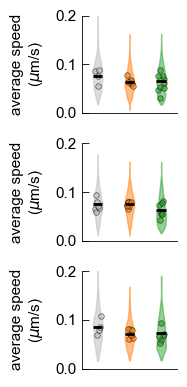

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths] 

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]
    #print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                # Use 2D or 3D displacement depending on z availability
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60)  # μm/sec
                

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
            # print(speed_prep)

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)
                #print(f"  {celltype}: {len(speed_prep)} cells, mean {np.mean(speed_prep):.4f}")

        # Plot violin if there’s data
        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=2, zorder=10)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    
    a.set_yticks([0.0, 0.1, 0.2, 0.3])
    a.set_ylim(0, 0.2)
    a.set_ylabel('average speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()

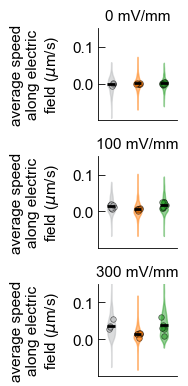

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths]

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                x = d['x'].values
                dx = np.diff(x)
                speed_x = dx / (interval * 60)  # μm/sec

                if len(speed_x) > 0:
                    speed_prep.append(np.mean(speed_x))

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)

        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=2, zorder=10)
            ax[ax_idx].set_title(str(int(E)*100)+' mV/mm', fontsize = 11)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_yticks([0.0, 0.1, 0.2, 0.3])
    a.set_ylim(-0.1, 0.15)
    a.set_ylabel('average speed\nalong electric\n' + r'field ($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()

# Directionality (average cosine theta)

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_213/1976529988.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.8, 1])


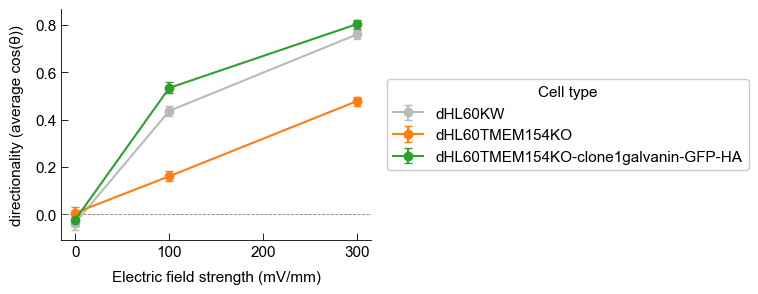

In [21]:
def calc_cos_theta_net_per_trajectory(df):
    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']
    results = []

    for name, group in df.groupby(group_cols):
        dx = group['x'].iloc[-1] - group['x'].iloc[0]
        dy = group['y'].iloc[-1] - group['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)

        cos_theta = np.nan if norm == 0 else np.dot(v, e_field) / norm

        # name is a tuple matching group_cols
        row = dict(zip(group_cols, name))
        row['cos_theta_net'] = cos_theta
        results.append(row)

    return pd.DataFrame(results)


df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(figsize=(4,3))

for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax.errorbar(
        group['E_V_cm'] * 100,  # convert to mV/mm
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        lw=1.5,
        color=color_dict[celltype]
    )

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('directionality (average cos(θ))')
# ax.set_title('Alignment of Net Trajectory with Electric Field')

# Move legend to the right
ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

# Autocorrelation Analysis

 This uses cosine theta between trajectory vector and electric field (the regular approach we've been taking).

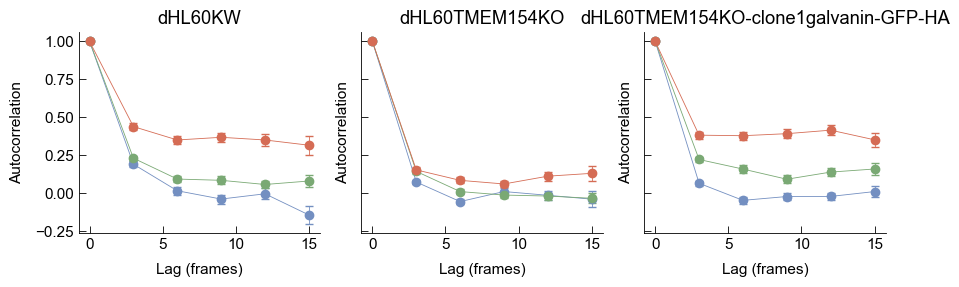

In [22]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr


autocorr_list = []
for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=3, marker='o'
        )
    ax.set_title(celltype)
    ax.set_xlabel('Lag (frames)')
    ax.set_ylabel('Autocorrelation')
    # ax.legend()
plt.tight_layout()
plt.show()

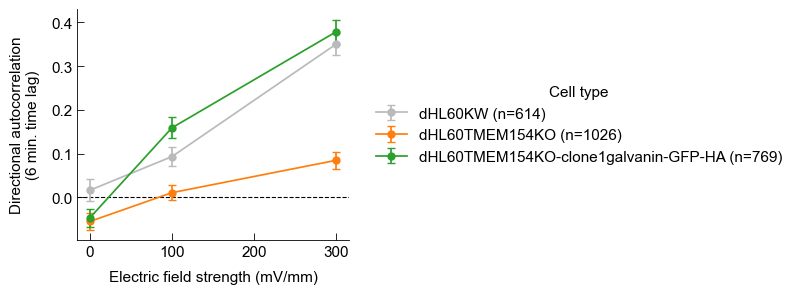

In [28]:
lag_to_plot = 6  # in frames; 6-minute lag corresponds to lag=6 frames at 1-minute intervals

df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]  

fig, ax = plt.subplots(figsize=(3.5, 3))

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    
    ax.errorbar(
        x=d_sorted.E_V_cm.values * 100,  # converting to mV/mm
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', markersize=5, lw=1.25, capsize=3, zorder=10, color = color_dict[g]
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)

# ax.set_xlim(-5, 350)
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('Directional autocorrelation\n(6 min. time lag)')

ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

# plt.tight_layout()
plt.show()



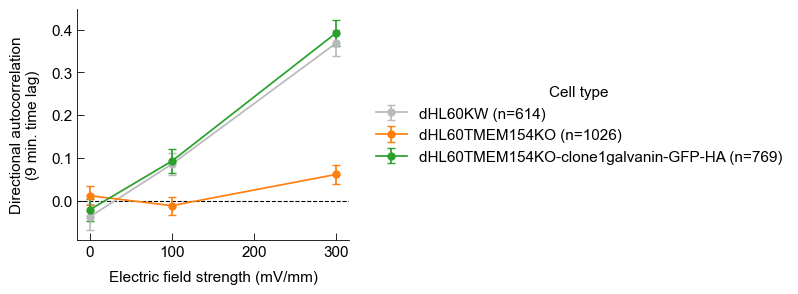

In [26]:
lag_to_plot = 9  # in frames; 6-minute lag corresponds to lag=6 frames at 1-minute intervals

df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]  

fig, ax = plt.subplots(figsize=(3.5, 3))

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    
    ax.errorbar(
        x=d_sorted.E_V_cm.values * 100,  # converting to mV/mm
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', markersize=5, lw=1.25, capsize=3, zorder=10, color = color_dict[g]
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)

# ax.set_xlim(-5, 350)
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('Directional autocorrelation\n(9 min. time lag)')

ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

# plt.tight_layout()
plt.show()



## Autocorrelation, but relative to 0 mV/mm condition.

Here we plot relative to the 0 mV/mm condition to try to account for residual persistence in the absence of an electric field.  (i.e. subtraction of autocorrelation value from the 0 mV/mm condition).

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_60724/195124339.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


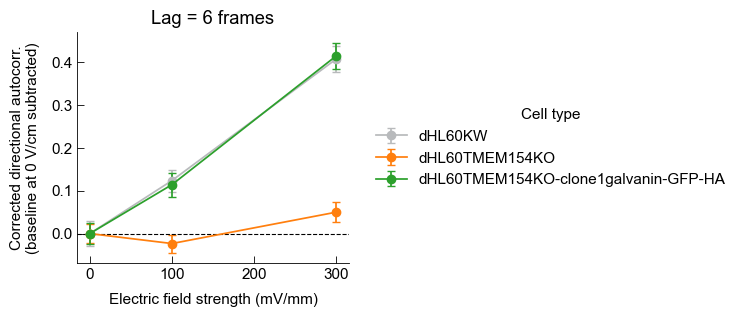

In [57]:
# Select lag to plot
lag_to_plot = 6  # frames (or 6 min if 1 frame = 1 min)

# Filter for selected lag
df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot].copy()

# Get baseline autocorrelation at 0 V/cm for each celltype
baseline = df_plot[df_plot.E_V_cm == 0].set_index('celltype')['mean_autocorr'].to_dict()

fig1, ax1 = plt.subplots(figsize=(3.5, 3))

for celltype, group in df_plot.groupby('celltype'):
    baseline_val = baseline.get(celltype, np.nan)
    if pd.isna(baseline_val):
        continue  # skip if baseline missing

    d_sorted = group.sort_values('E_V_cm')
    corrected = d_sorted['mean_autocorr'] - baseline_val

    ax1.errorbar(
        d_sorted.E_V_cm * 100,  # convert to mV/mm
        corrected,
        yerr=d_sorted.sem_autocorr,  # keep SEM as is
        label=celltype,
        marker='o', capsize=3, lw=1.25,
        color=color_dict.get(celltype, 'gray')
    )

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Electric field strength (mV/mm)')
ax1.set_ylabel('Corrected directional autocorr.\n(baseline at 0 V/cm subtracted)')
ax1.set_title(f'Lag = {lag_to_plot} frames')
ax1.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

plt.tight_layout()
plt.show()